# Improved fitting for the LiF on fused quartz data.

I have found two problems with the current fitting methods. 

First, the parameters are widely different in magnitude which leads to poor numerical conditioning in the Hessian matrix. The solution is to build scaling into the fitting equation so that all the parameters end up having similar magnitudes. Since the magnitudes are hard to predict in advance I will make the scaling parameters adjustable as members of the Data class.

Second, I am seeing structure in the residual plots for the data from the fused quartz plate that suggests that the fitting function is inadequate. At the moment I am using an even order only quartic function. Because I can see some qintic shape in the residual I will extend the function to a full quintic.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from DepositData5 import DepositData

In [2]:
g1mm = DepositData.from_file('Run9_17_WA0904_1mm.txt', 'Glass 1mm')

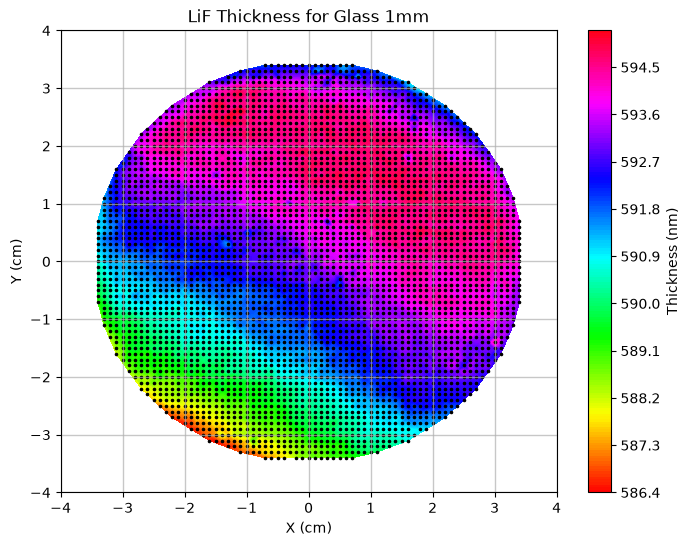

In [3]:
g1mm.Ron_plot()

In [4]:
# Scaled initial parameters
ipg = [ 5.938,  1.045e+00, -9.325,  1.174,  1.0,  1.0, 1.0]

def quint_fit(p, a):
    return DepositData.fit_helper(p, a, 'angled_quintic')


In [5]:
g1f =g1mm.fit_to(quint_fit, ipg)
print(g1f)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 516.648295125003
        x: [ 5.934e+00  1.051e+00 -9.354e-01  2.278e+00 -4.104e-01
             5.943e-01  1.000e+00]
      nit: 17
      jac: [-7.629e-05  2.518e-04 -9.918e-05 -2.060e-04  3.052e-05
             4.578e-05  0.000e+00]
 hess_inv: [[ 2.953e-08 -5.480e-09 ... -3.534e-06  0.000e+00]
            [-5.480e-09  2.956e-05 ...  2.353e-05  0.000e+00]
            ...
            [-3.534e-06  2.353e-05 ...  3.798e-03  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]]
     nfev: 232
     njev: 29


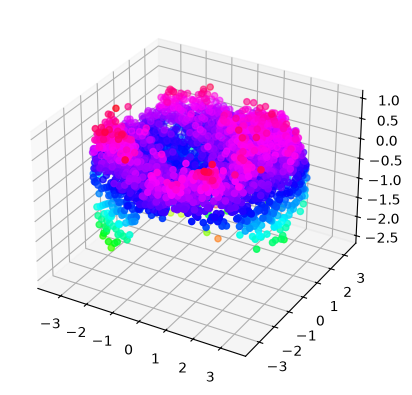

In [7]:
g1mm.resid_plot3D()

So now the residual is essentially radially symmetric.

I wonder if we would do a better job fitting these with cylindrical functions? It would certainly make Chris Crawford happy! I'll try that in the future. For now we want to compare with the older 2mm data.

In [8]:
S4 = DepositData.from_file('Run6_26_Scan4.txt', 'Scan4')

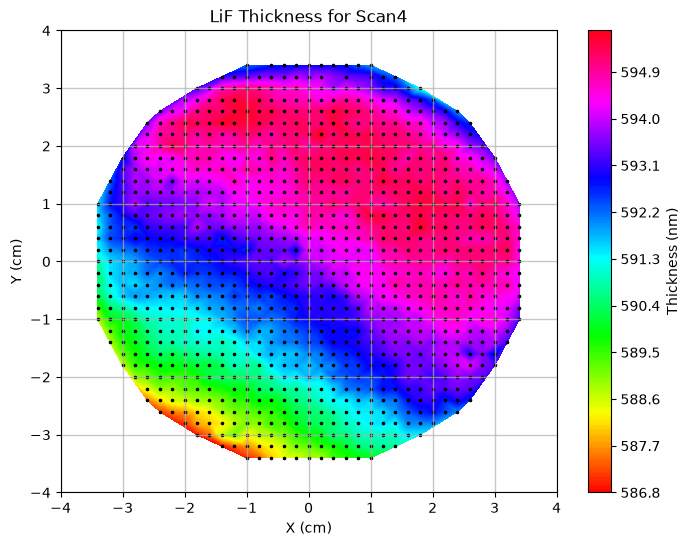

In [9]:
S4.Ron_plot()

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 161.8503263621703
        x: [ 5.940e+00  1.039e+00 -9.654e-01  2.394e+00 -4.061e-01
             5.815e-01  1.000e+00]
      nit: 18
      jac: [ 9.232e-04  3.548e-04  6.046e-04  2.460e-04  3.471e-04
             6.847e-04  0.000e+00]
 hess_inv: [[ 1.131e-07  1.363e-07 ... -1.360e-05  0.000e+00]
            [ 1.363e-07  1.025e-04 ...  2.167e-05  0.000e+00]
            ...
            [-1.360e-05  2.167e-05 ...  1.364e-02  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]]
     nfev: 240
     njev: 30


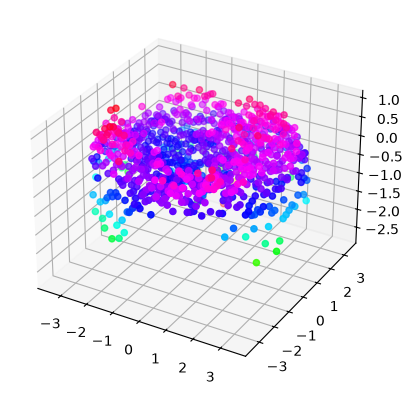

In [10]:
S4f =S4.fit_to(quint_fit, ipg)
print(S4f)
S4.resid_plot3D()

There is still a difference between the means and the angles are coming in as slightly different. Because of that I can't do the simple fit subtraction. I can, however, get a look at the difference in shape by setting the angle to zero in both fits and then looking at the difference.

In [11]:
S4params = S4f.x
S4params[1] = 0
S4fit0 = S4.angled_quintic(S4params)

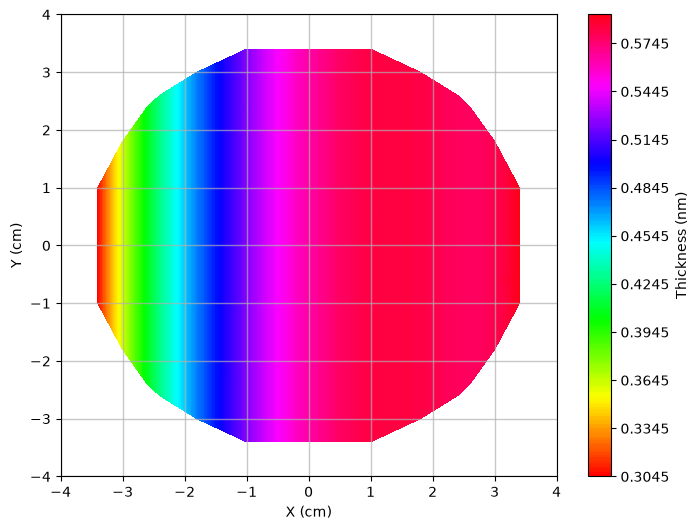

In [12]:
g1params = g1f.x
g1params[1] = 0
g1fit0 = S4.angled_quintic(g1params)
diff0 = S4fit0 - g1fit0
S4.contour_plot(diff0)

So ALL the difference is a slight slope across the wafer. This is some kind of measurement issue not a real difference. This says that the measurement process noise is REALLY low and the issues that we are seeing are almost certainly ones of alignment.